<a href="https://colab.research.google.com/github/Gunasalini/student-performance-data-science/blob/main/Week_2_Advanced_Data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2: Advanced Data Visualization and Storytelling with Python

## Student Performance Data Analysis

This project uses advanced data visualization techniques to explore patterns, relationships, and key factors influencing student academic performance. The objective is to transform raw data into meaningful visual stories that can be easily understood by a non-technical audience.

In [7]:
from google.colab import files
uploaded = files.upload()

Saving student+performance.zip to student+performance.zip


In [8]:
import zipfile
import os

with zipfile.ZipFile("student+performance.zip", "r") as zip_ref:
    zip_ref.extractall("student_data")

print(os.listdir("student_data"))
with zipfile.ZipFile("student_data/student.zip", "r") as zip_ref:
    zip_ref.extractall("student_data/extracted")

print(os.listdir("student_data/extracted"))
for root, dirs, files in os.walk("student_data"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

['.student.zip_old', 'student.zip']
['student-por.csv', 'student.txt', 'student-merge.R', 'student-mat.csv']
student_data/extracted/student-por.csv
student_data/extracted/student-mat.csv


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
mat_df = pd.read_csv("student_data/extracted/student-mat.csv", sep=";")
por_df = pd.read_csv("student_data/extracted/student-por.csv", sep=";")
mat_df["subject"] = "Mathematics"
por_df["subject"] = "Portuguese"
df = pd.concat([mat_df, por_df], ignore_index=True)
print("Mathematics dataset shape:", mat_df.shape)
print("Portuguese dataset shape:", por_df.shape)
print("Combined dataset shape:", df.shape)
df.head()

Mathematics dataset shape: (395, 34)
Portuguese dataset shape: (649, 34)
Combined dataset shape: (1044, 34)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,Mathematics
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,Mathematics
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,Mathematics
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,Mathematics
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,Mathematics


Visualization 1 — Final Grade Distribution by Subject


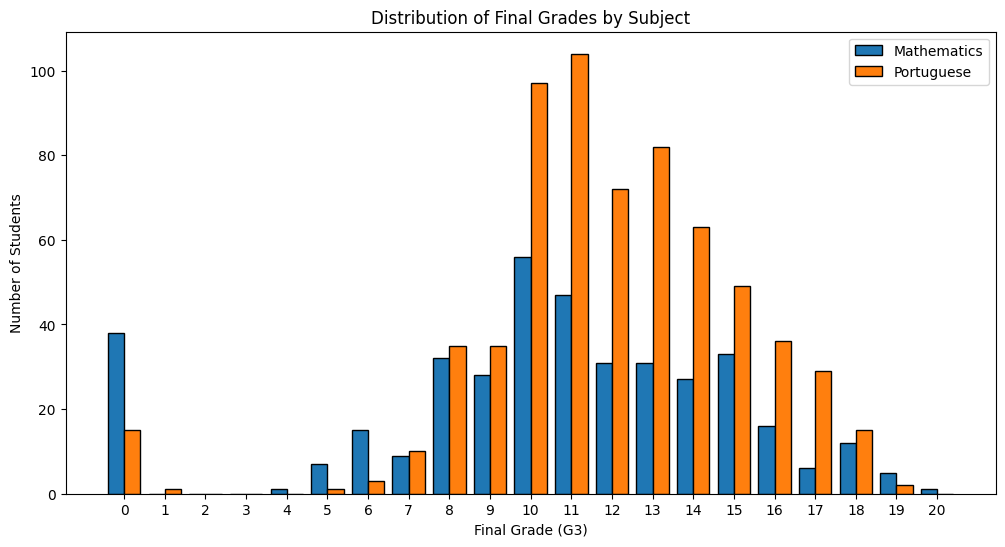

In [10]:
import numpy as np
import matplotlib.pyplot as plt
math_counts = mat_df["G3"].value_counts().sort_index()
por_counts = por_df["G3"].value_counts().sort_index()
grades = np.arange(0, 21)
math_values = [math_counts.get(grade, 0) for grade in grades]
por_values = [por_counts.get(grade, 0) for grade in grades]
width = 0.4
plt.figure(figsize=(12, 6))
plt.bar(
    grades - width/2,
    math_values,
    width=width,
    label="Mathematics",
    edgecolor="black"
)

plt.bar(
    grades + width/2,
    por_values,
    width=width,
    label="Portuguese",
    edgecolor="black"
)

plt.title("Distribution of Final Grades by Subject")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.xticks(grades)
plt.legend()

plt.show()

Visualization 2: Study Time vs Final Grade

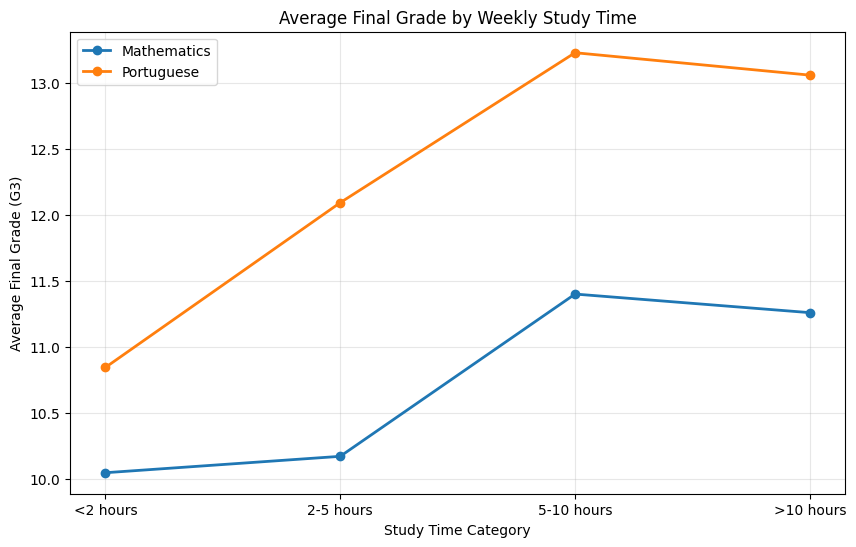

In [11]:
study_performance = df.groupby(
    ["studytime", "subject"]
)["G3"].mean().reset_index()
plt.figure(figsize=(10, 6))
for subject in study_performance["subject"].unique():
    data = study_performance[
        study_performance["subject"] == subject
    ]
    plt.plot(
        data["studytime"],
        data["G3"],
        marker="o",
        linewidth=2,
        label=subject
    )
plt.title("Average Final Grade by Weekly Study Time")
plt.xlabel("Study Time Category")
plt.ylabel("Average Final Grade (G3)")
plt.xticks(
    [1, 2, 3, 4],
    ["<2 hours", "2-5 hours", "5-10 hours", ">10 hours"]
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Visualization 3: Impact of Absences on Final Grades

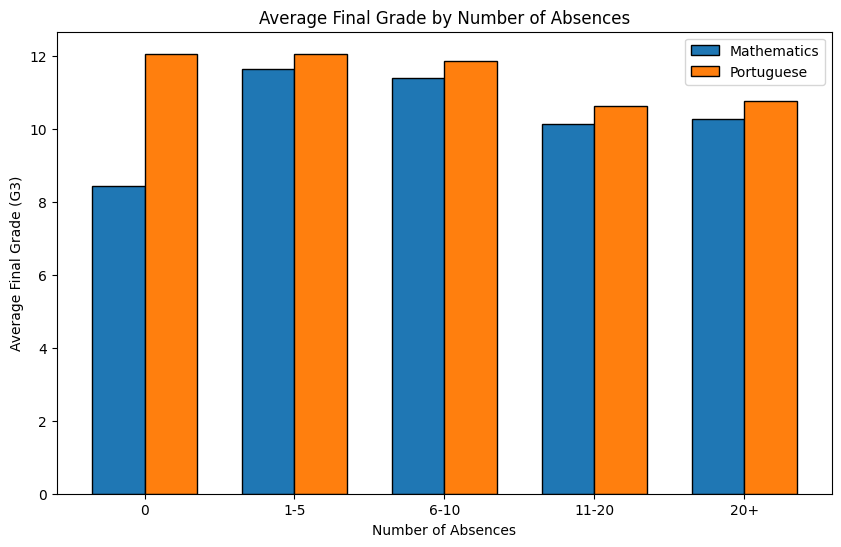

In [12]:
df["absence_group"] = pd.cut(
    df["absences"],
    bins=[-1, 0, 5, 10, 20, df["absences"].max()],
    labels=["0", "1-5", "6-10", "11-20", "20+"]
)
absence_performance = df.groupby(
    ["absence_group", "subject"],
    observed=True
)["G3"].mean().reset_index()
groups = absence_performance["absence_group"].unique()
x = np.arange(len(groups))
width = 0.35
math_data = absence_performance[
    absence_performance["subject"] == "Mathematics"
].set_index("absence_group").reindex(groups)["G3"]
por_data = absence_performance[
    absence_performance["subject"] == "Portuguese"
].set_index("absence_group").reindex(groups)["G3"]
plt.figure(figsize=(10, 6))
plt.bar(
    x - width / 2,
    math_data,
    width,
    label="Mathematics",
    edgecolor="black"
)
plt.bar(
    x + width / 2,
    por_data,
    width,
    label="Portuguese",
    edgecolor="black"
)
plt.title("Average Final Grade by Number of Absences")
plt.xlabel("Number of Absences")
plt.ylabel("Average Final Grade (G3)")
plt.xticks(x, groups)
plt.legend()
plt.show()

Visualization 4: Correlation Heatmap of Academic Factors

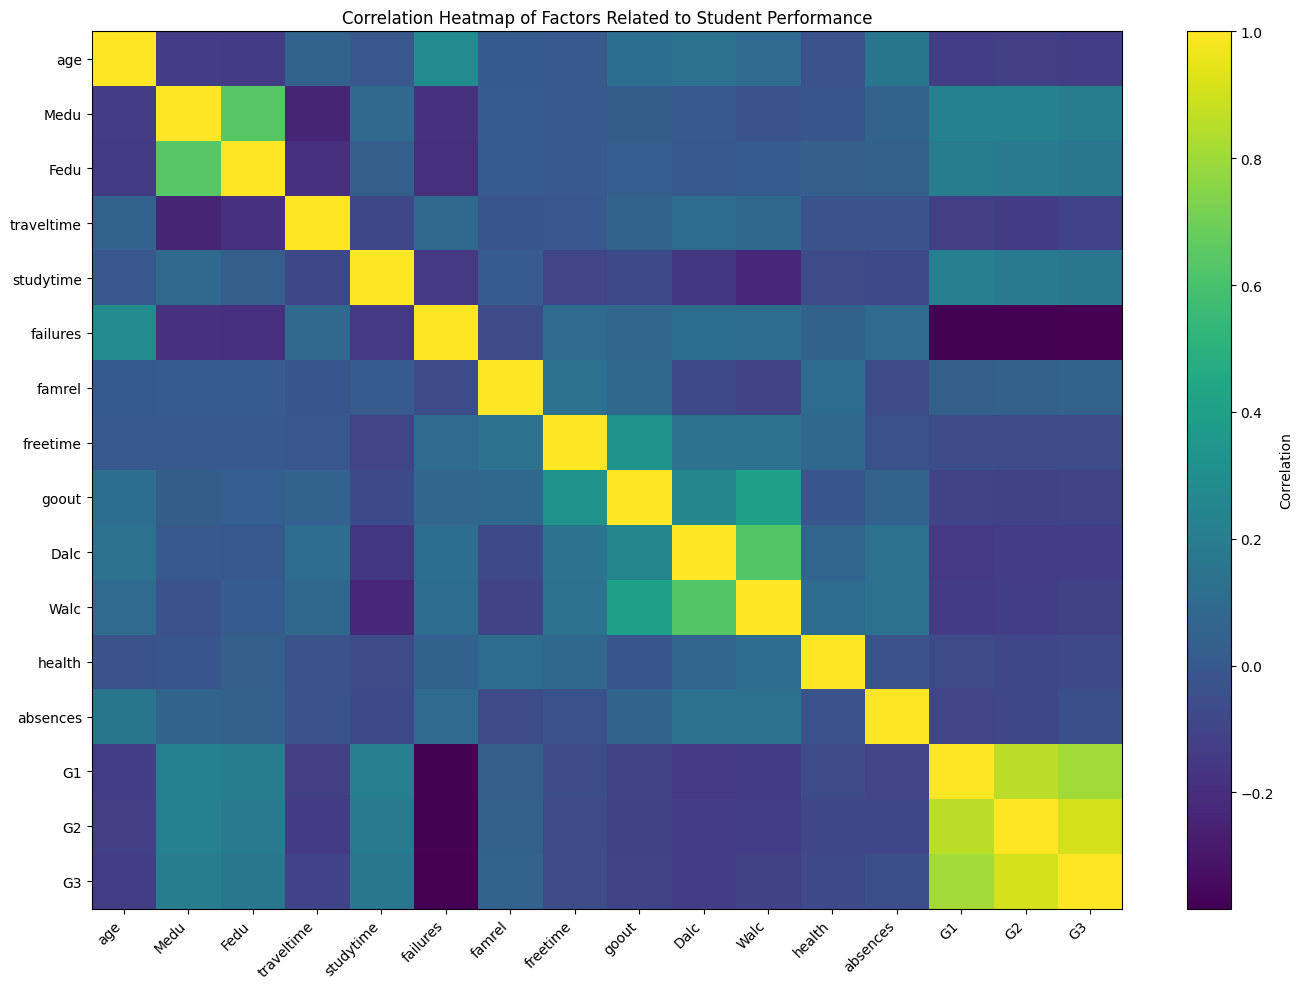

In [13]:
correlation_columns = [
    "age",
    "Medu",
    "Fedu",
    "traveltime",
    "studytime",
    "failures",
    "famrel",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health",
    "absences",
    "G1",
    "G2",
    "G3"
]
correlation_matrix = df[correlation_columns].corr()
plt.figure(figsize=(14, 10))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(correlation_columns)),
    correlation_columns
)
plt.title("Correlation Heatmap of Factors Related to Student Performance")
plt.tight_layout()
plt.show()

Visualization 5: Previous Failures vs Final Grade

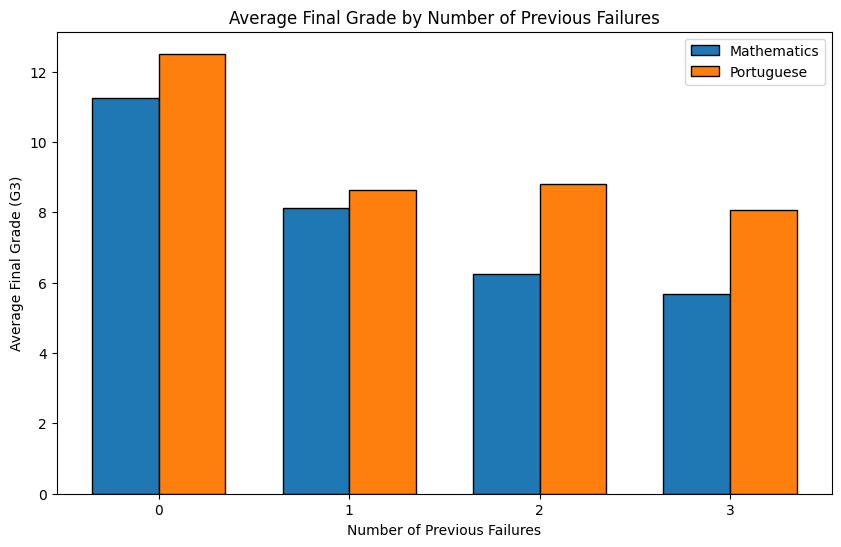

In [14]:
failure_performance = df.groupby(
    ["failures", "subject"]
)["G3"].mean().reset_index()
failure_levels = sorted(df["failures"].unique())
x = np.arange(len(failure_levels))
width = 0.35
math_failure = failure_performance[
    failure_performance["subject"] == "Mathematics"
].set_index("failures").reindex(failure_levels)["G3"]
por_failure = failure_performance[
    failure_performance["subject"] == "Portuguese"
].set_index("failures").reindex(failure_levels)["G3"]
plt.figure(figsize=(10, 6))
plt.bar(
    x - width / 2,
    math_failure,
    width,
    label="Mathematics",
    edgecolor="black"
)
plt.bar(
    x + width / 2,
    por_failure,
    width,
    label="Portuguese",
    edgecolor="black"
)
plt.title("Average Final Grade by Number of Previous Failures")
plt.xlabel("Number of Previous Failures")
plt.ylabel("Average Final Grade (G3)")
plt.xticks(x, failure_levels)
plt.legend()
plt.show()

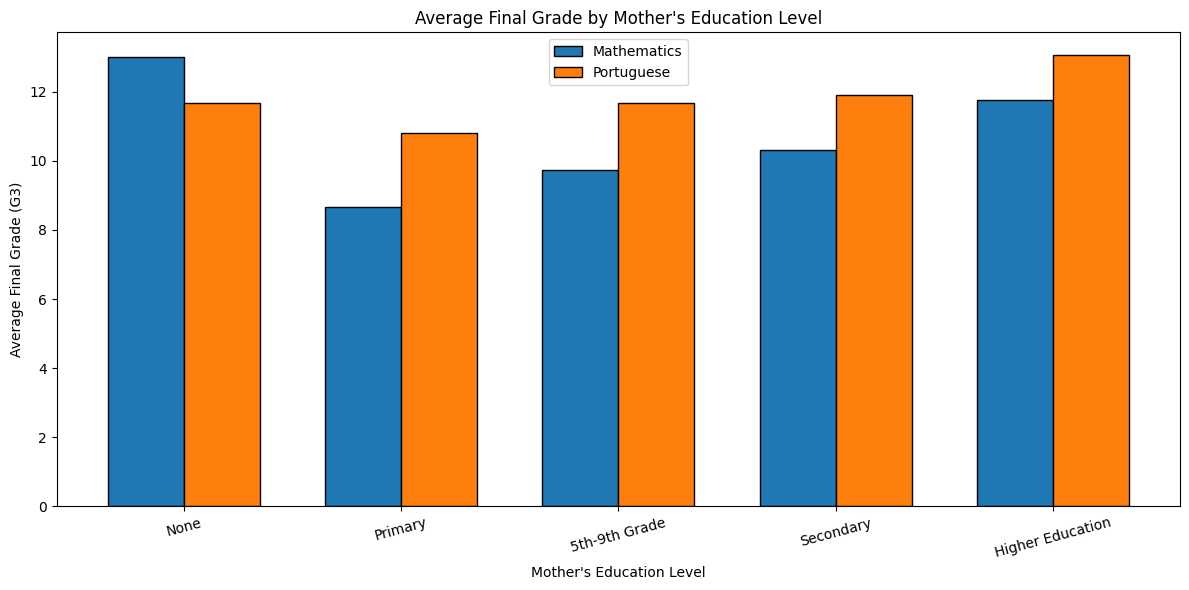

In [15]:
education_performance = df.groupby(
    ["Medu", "subject"]
)["G3"].mean().reset_index()
education_levels = [0, 1, 2, 3, 4]
education_labels = [
    "None",
    "Primary",
    "5th-9th Grade",
    "Secondary",
    "Higher Education"
]

x = np.arange(len(education_levels))
width = 0.35
math_education = education_performance[
    education_performance["subject"] == "Mathematics"
].set_index("Medu").reindex(education_levels)["G3"]
por_education = education_performance[
    education_performance["subject"] == "Portuguese"
].set_index("Medu").reindex(education_levels)["G3"]
plt.figure(figsize=(12, 6))
plt.bar(
    x - width / 2,
    math_education,
    width,
    label="Mathematics",
    edgecolor="black"
)
plt.bar(
    x + width / 2,
    por_education,
    width,
    label="Portuguese",
    edgecolor="black"
)
plt.title("Average Final Grade by Mother's Education Level")
plt.xlabel("Mother's Education Level")
plt.ylabel("Average Final Grade (G3)")
plt.xticks(x, education_labels, rotation=15)
plt.legend()
plt.tight_layout()
plt.show()